# Predicción de ventas mensuales utilizando un modelo SARIMA

In [43]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## Exploración de los datos

In [5]:
datapath = "../../src/data/"

In [7]:
dataset = pd.read_csv(
    f"{datapath}stores_sales_forecasting.csv",
    encoding="latin-1",
    encoding_errors="replace"
)
dataset.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [8]:
dataset.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,2121.0,NaN,NaN,NaN,5041.643564,2885.740258,1.0,2568.0,5145.0,7534.0,9991.0
Order ID,2121,1764,CA-2016-157749,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,2121,889,9/5/2016,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,2121,960,12/16/2015,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,2121,4,Standard Class,1248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,2121,707,SV-20365,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,2121,707,Seth Vernon,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,2121,3,Consumer,1113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,2121,1,United States,2121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,2121,371,New York City,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
dataset.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [11]:
dataset['Order Date'] = pd.to_datetime(dataset['Order Date'])

In [12]:
dataset['Order Date'].unique()

<DatetimeArray>
['2016-11-08 00:00:00', '2015-10-11 00:00:00', '2014-06-09 00:00:00',
 '2017-07-16 00:00:00', '2015-09-25 00:00:00', '2015-09-17 00:00:00',
 '2016-12-08 00:00:00', '2015-12-27 00:00:00', '2015-04-18 00:00:00',
 '2016-06-17 00:00:00',
 ...
 '2014-08-15 00:00:00', '2015-03-26 00:00:00', '2017-01-14 00:00:00',
 '2016-06-06 00:00:00', '2015-10-10 00:00:00', '2017-01-29 00:00:00',
 '2016-06-03 00:00:00', '2017-06-01 00:00:00', '2015-03-19 00:00:00',
 '2014-01-21 00:00:00']
Length: 889, dtype: datetime64[us]

In [14]:
monthly_sales = dataset.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum()

In [ ]:
monthly_sales.shape

(48,)

In [16]:
monthly_sales.describe()

count       48.000000
mean     15458.329069
std       9103.800668
min       1839.658000
25%       9297.702400
50%      12650.437500
75%      21644.671575
max      37056.715000
Name: Sales, dtype: float64

In [17]:
monthly_sales.head()

Order Date
2014-01-01     6242.525
2014-02-01     1839.658
2014-03-01    14573.956
2014-04-01     7944.837
2014-05-01     6912.787
Freq: MS, Name: Sales, dtype: float64

<Axes: xlabel='Mes', ylabel='Ventas mensuales'>

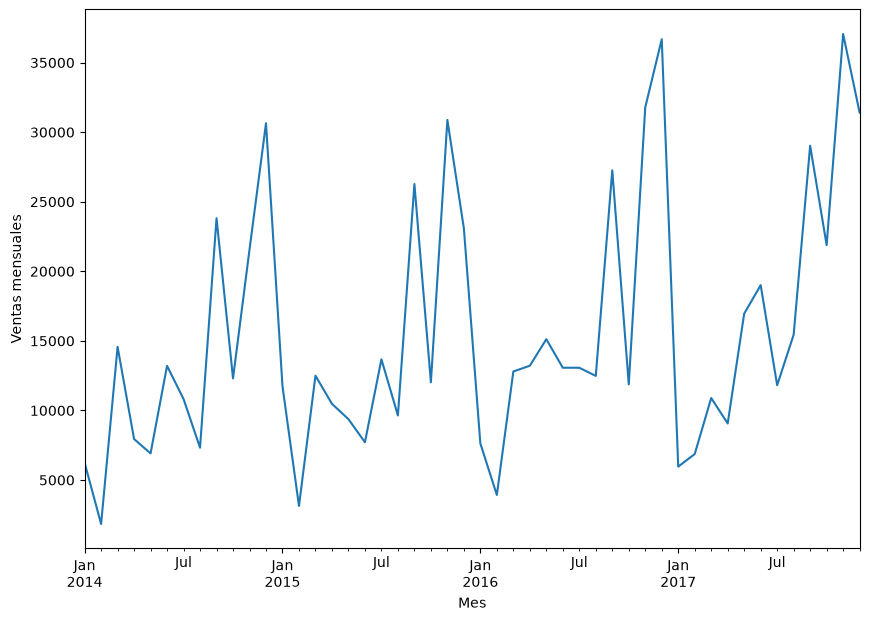

In [22]:
monthly_sales.plot(figsize=(10, 7), xlabel='Mes', ylabel="Ventas mensuales")

## Test de Dickey-Fuller para verificar estacionariedad

In [24]:
adf_test = adfuller(monthly_sales, maxlag=12, regression='ct')

adf_valor = adf_test[0] 
val_criticos = adf_test[4]
# H0: no existe evidencia de estacionariedad
# H1: existe evidencia de estacionariedad

In [ ]:
print(f"Estadístico ADF: {adf_valor}")
#Como estadístico ADF < 1%, entonces existe evidencia fuerte de estacionariedad

Estadístico ADF: -2.1439422051993424


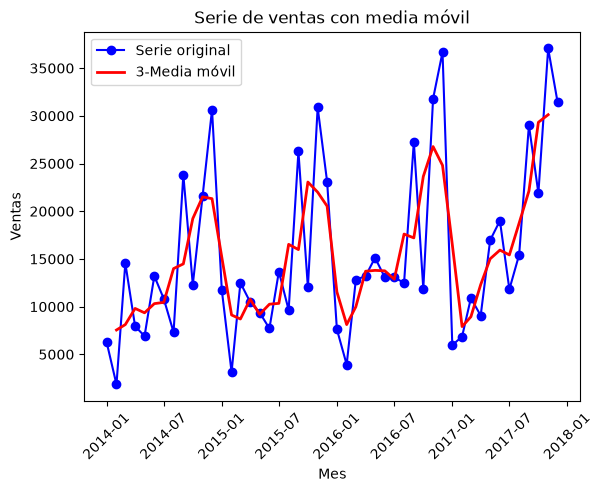

In [27]:
ma = 3
ma_data = monthly_sales.rolling(window=ma, center=True).mean()

# Gráfico de la serie de datos original
plt.Figure(figsize=(10, 5))
plt.plot(monthly_sales, label="Serie original", marker='o', linestyle='-', color='blue')
# Gráfico de la media móvil
plt.plot(ma_data, label=f"{ma}-Media móvil", color='red', linewidth=2)

# Add labels and title
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.title("Serie de ventas con media móvil")
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

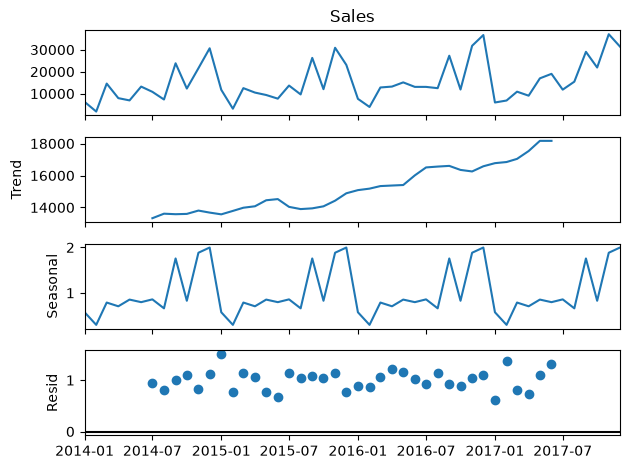

In [30]:
ventas_descomp = seasonal_decompose(monthly_sales, model='multiplicative', period=12)

ventas_descomp.plot()
plt.show()

In [ ]:
#H0: No exisiste evidencia de autocorrelación
#H1: Existe evidencia fuerte de autocorrelación
lb_test = acorr_ljungbox(monthly_sales, lags=[12], boxpierce=False)
print(lb_test)

      lb_stat  lb_pvalue
12  42.854398   0.000024


In [35]:
type(lb_test)

pandas.DataFrame

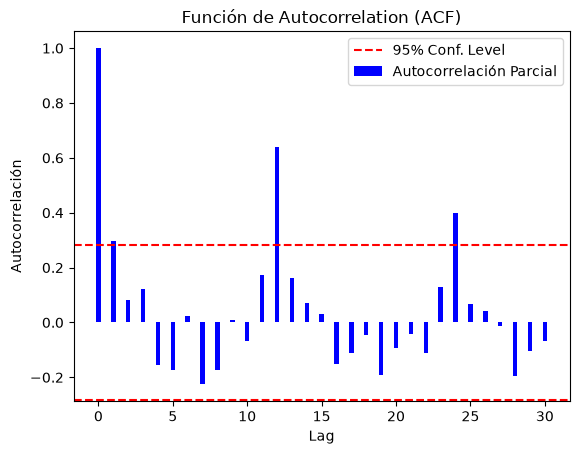

In [37]:
# Función de autocorrelación (ACF) y autocorrelación parcial (PACF)
n = len(monthly_sales)
acf_val, confint = acf(monthly_sales, nlags=30, alpha=0.05)

# Gráfico de ACF
plt.bar(range(len(acf_val)), acf_val, width=0.3, color='blue', label='Autocorrelación Parcial')

conf_level = 1.96 / np.sqrt(n)
plt.axhline(y=conf_level, color='red', linestyle='dashed', label="95% Conf. Level")
plt.axhline(y=-conf_level, color='red', linestyle='dashed')

plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.title("Función de Autocorrelation (ACF)")
plt.legend()
plt.show()

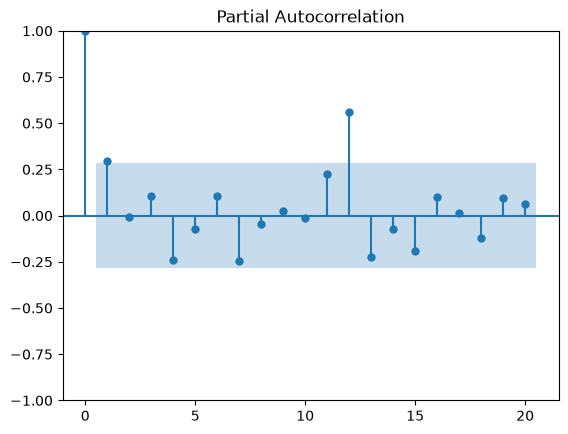

In [39]:
plot_pacf(monthly_sales, lags=20)
plt.show()

## Modelo ARIMA
Los análisis a la serie de tiempo muestran que los datos son candidatos a modelar con un modelo ARIMA.
Las pruebas de autocorrelación y autocorrelación parcial muestran valores significativos para los retardos 1, y 12.

In [40]:
meses = 3
monthly_sales_train = monthly_sales.iloc[0:len(monthly_sales) - meses]
monthly_sales_test = monthly_sales.tail(meses)
print(f"Total de observaciones para entrenamiento: {len(monthly_sales_train)}")
print(f"Total de observaciones para prueba: {len(monthly_sales_test)}")

Total de observaciones para entrenamiento: 45
Total de observaciones para prueba: 3


In [46]:
#SARIMA=(p,d,q)x(P,D,Q,S)
#Nuestro modelo puede tener la forma: ARIMA=(p, 1, q)x(0, 1, 0, 12)
import warnings
# Suprime las warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=FutureWarning)

mejor_aic = float("inf")
mejores_param = None

for p, q in itertools.product(range(3), range(3)):
    try:
        model = ARIMA(monthly_sales_train, order=(p, 1, q), seasonal_order=(0, 1, 0, 12)).fit()
        if model.aic < mejor_aic:
            mejor_aic = model.aic
            mejores_param = (p, 1, q)
    except Exception:
        continue

print(f"Mejores parámetros: {mejores_param}")
print(f"Mejor AIC: {mejor_aic}")

Mejores parámetros: (1, 1, 1)
Mejor AIC: 648.8106589668276
